# AML Project 4:  Non Linearity, Tree Based classification, SVM

Sections:
- Part 1: EDA + baseline + non-linear models + SVM
- Part 2: Tree-based methods with diagnostic plots
- Final comparison table

## 1. Setup

In [53]:
!pip -q install kagglehub[pandas-datasets] scikit-learn pandas numpy matplotlib seaborn

## 2. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    log_loss, precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder, OneHotEncoder, PolynomialFeatures, RobustScaler, SplineTransformer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

## 3. Load Dataset

In [2]:
bank_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'janiobachmann/bank-marketing-dataset',
    'bank.csv',
)

print('Bank data shape:', bank_df.shape)
display(bank_df.head())

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Bank data shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
bank_df['poutcome'].value_counts()

,count
poutcome,
unknown,8326
failure,1228
success,1071
other,537


## 4. Part 1: EDA and Non-Linear / SVM Workflow

In [56]:
bank_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [57]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


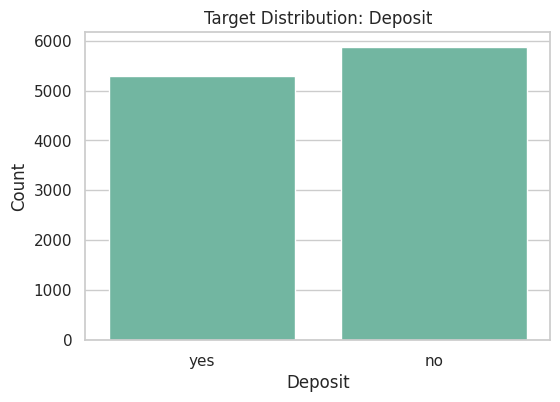

deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64


In [58]:
plt.figure(figsize=(6, 4))
sns.countplot(data=bank_df, x='deposit')
plt.title('Target Distribution: Deposit')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.show()

print(bank_df['deposit'].value_counts(normalize=True))

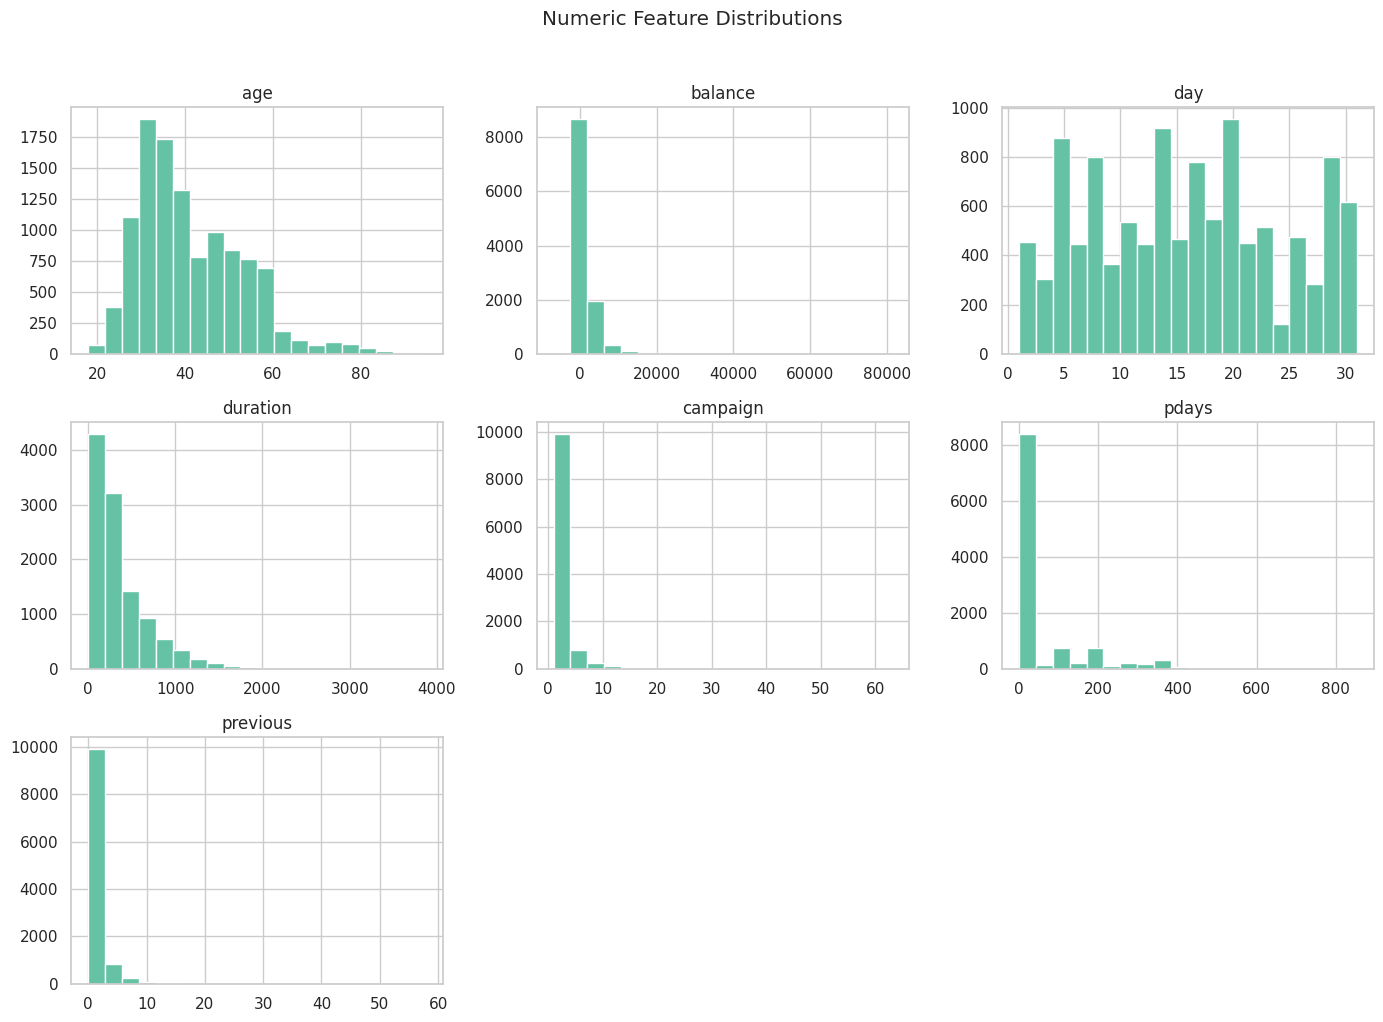

In [59]:
numeric_cols = bank_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

bank_df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

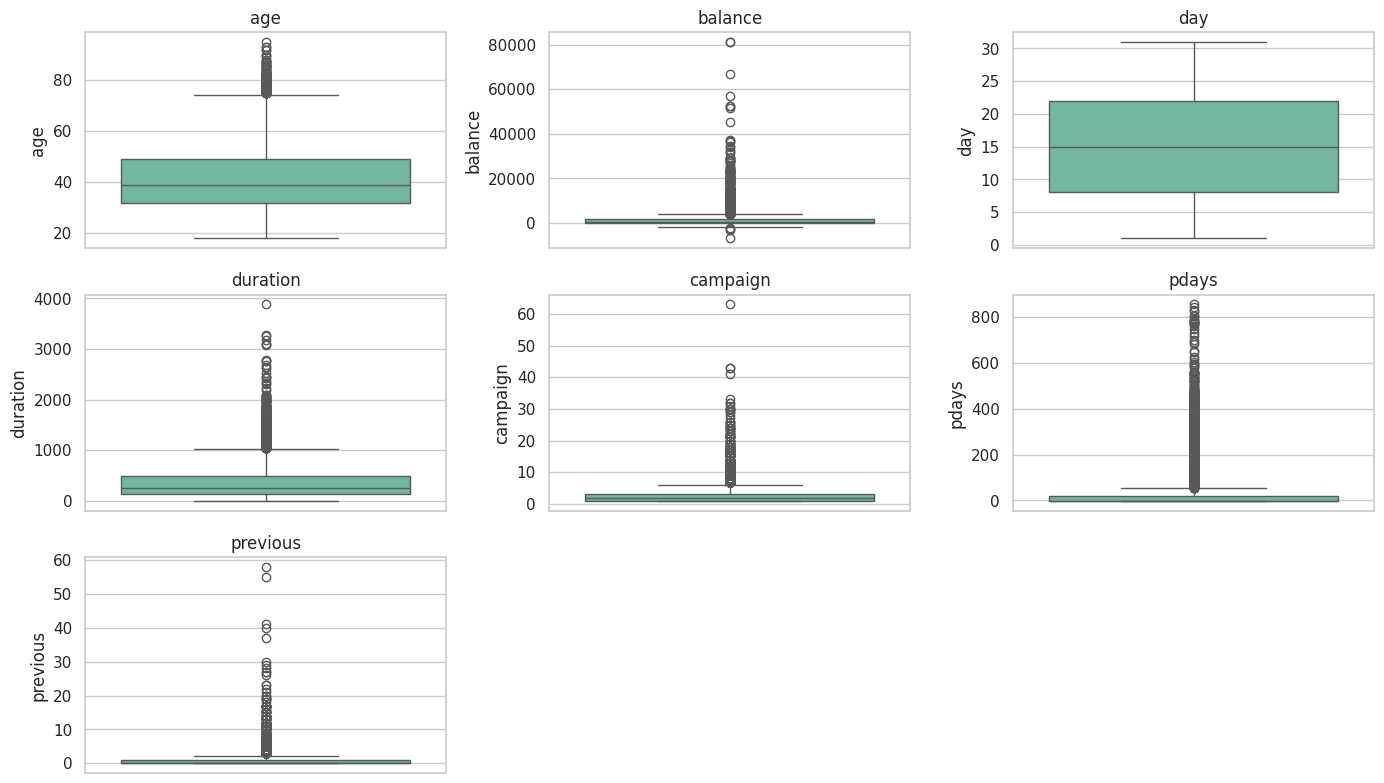

In [60]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=bank_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

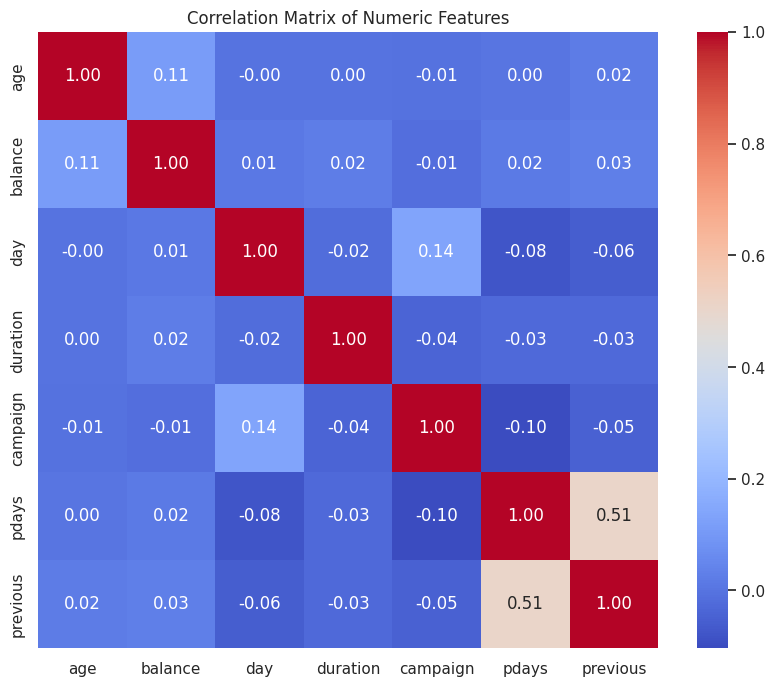

In [61]:
plt.figure(figsize=(10, 8))
corr = bank_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### 4.1 Preprocessing for Baseline / Non-Linear / SVM

In [62]:
df = bank_df.copy()
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

df['deposit'] = (
    df['deposit']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

df = df.dropna(subset=['deposit']).reset_index(drop=True)
df['deposit'] = df['deposit'].astype(int)

X = df.drop(columns=['deposit']).copy()
y = df['deposit'].copy()

if 'duration' in X.columns:
    X = X.drop(columns=['duration'])

if 'pdays' in X.columns:
    X['was_previously_contacted'] = (X['pdays'] != -1).astype(int)
    X['pdays_clean'] = X['pdays'].replace(-1, 0)
    X = X.drop(columns=['pdays'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('\nNumeric features:')
print(numeric_features)
print('\nCategorical features:')
print(categorical_features)
print('\nTarget distribution:')
print(y.value_counts(normalize=True))

X_train shape: (8371, 16)
X_test shape: (2791, 16)

Numeric features:
['age', 'balance', 'day', 'campaign', 'previous', 'was_previously_contacted', 'pdays_clean']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Target distribution:
deposit
0    0.52616
1    0.47384
Name: proportion, dtype: float64


In [63]:
def make_scaled_cls_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', RobustScaler()),
                ]),
                numeric_features,
            ),
            (
                'cat',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]),
                categorical_features,
            ),
        ]
    )


def evaluate_classification_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
    }

In [64]:
baseline_model = Pipeline([
    ('preprocessor', make_scaled_cls_preprocessor()),
    ('model', LogisticRegression(max_iter=5000))
])

baseline_result = evaluate_classification_model(
    'Baseline Logistic Regression', baseline_model,
    X_train, X_test, y_train, y_test
)

baseline_results = pd.DataFrame([baseline_result])
display(baseline_results)

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline Logistic Regression,0.696883,0.736111,0.561271,0.63691,0.757358


In [65]:
top_numeric_features = ['pdays_clean', 'previous', 'balance']
print('Top numeric features for non-linear transformations:')
print(top_numeric_features)

def nonlinear_numeric_preprocessor(selected, transformer):
    other_numeric = [c for c in numeric_features if c not in selected]
    return ColumnTransformer(
        transformers=[
            ('selected_num', transformer, selected),
            ('other_num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
            ]), other_numeric),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), categorical_features),
        ],
        remainder='drop'
    )

gam_preprocessor = ColumnTransformer(
    transformers=[
        *[
            (
                f'spline_{feature}',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', RobustScaler()),
                    ('spline', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
                ]),
                [feature],
            )
            for feature in top_numeric_features
        ],
        ('other_num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
        ]), [c for c in numeric_features if c not in top_numeric_features]),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ],
    remainder='drop'
)

nonlinear_cls_models = {
    'Polynomial Logistic': Pipeline([
        ('preprocessor', nonlinear_numeric_preprocessor(
            top_numeric_features,
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ])
        )),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'Step Function Logistic': Pipeline([
        ('preprocessor', nonlinear_numeric_preprocessor(
            top_numeric_features,
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('bins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile')),
            ])
        )),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'Spline Logistic': Pipeline([
        ('preprocessor', nonlinear_numeric_preprocessor(
            top_numeric_features,
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('spline', SplineTransformer(n_knots=6, degree=3, include_bias=False)),
            ])
        )),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'Local Classification (KNN)': Pipeline([
        ('preprocessor', make_scaled_cls_preprocessor()),
        ('model', KNeighborsClassifier(n_neighbors=25))
    ]),
    'GAM-style Logistic': Pipeline([
        ('preprocessor', gam_preprocessor),
        ('model', LogisticRegression(max_iter=5000))
    ]),
}

Top numeric features for non-linear transformations:
['pdays_clean', 'previous', 'balance']


In [66]:
nonlinear_cls_results = []

for name, model in nonlinear_cls_models.items():
    nonlinear_cls_results.append(
        evaluate_classification_model(name, model, X_train, X_test, y_train, y_test)
    )

nonlinear_cls_df = pd.DataFrame(nonlinear_cls_results).sort_values(
    ['accuracy', 'f1', 'roc_auc'], ascending=False
).reset_index(drop=True)

display(nonlinear_cls_df)

,model,accuracy,precision,recall,f1,roc_auc
0,Spline Logistic,0.706915,0.746575,0.577156,0.651024,0.765268
1,Step Function Logistic,0.706557,0.740210,0.586233,0.654285,0.762634
2,GAM-style Logistic,0.704049,0.745059,0.570348,0.646101,0.762688
3,Polynomial Logistic,0.702616,0.744048,0.567322,0.643777,0.760845
4,Local Classification (KNN),0.691150,0.720729,0.568079,0.635364,0.751621


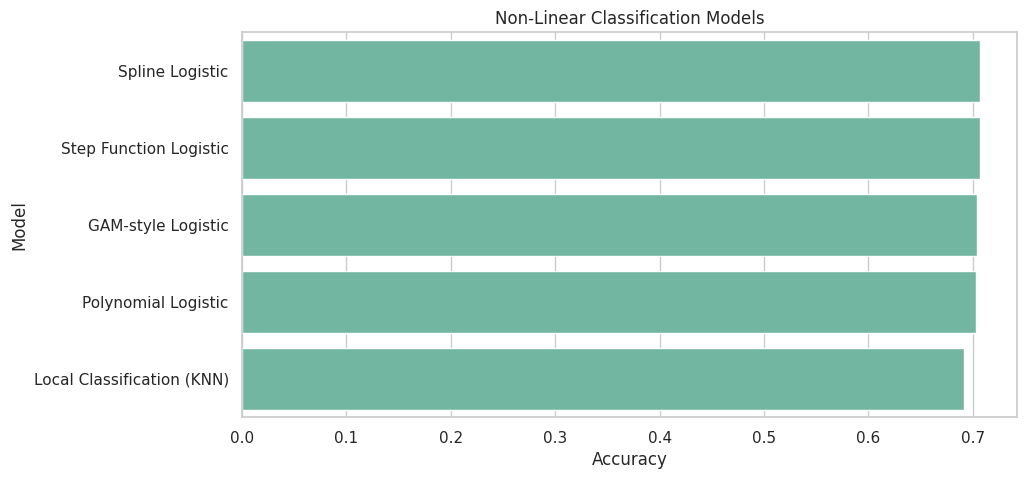

In [67]:
plt.figure(figsize=(10, 5))
sns.barplot(data=nonlinear_cls_df, x='accuracy', y='model')
plt.title('Non-Linear Classification Models')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.show()

In [68]:
svm_cls_models = {
    'SVM Linear': Pipeline([
        ('preprocessor', make_scaled_cls_preprocessor()),
        ('model', SVC(kernel='linear', probability=True))
    ]),
    'SVM Polynomial': Pipeline([
        ('preprocessor', make_scaled_cls_preprocessor()),
        ('model', SVC(kernel='poly', degree=3, probability=True))
    ]),
    'SVM RBF': Pipeline([
        ('preprocessor', make_scaled_cls_preprocessor()),
        ('model', SVC(kernel='rbf', probability=True))
    ]),
    'SVM Sigmoid': Pipeline([
        ('preprocessor', make_scaled_cls_preprocessor()),
        ('model', SVC(kernel='sigmoid', probability=True))
    ]),
}

svm_cls_results = []
for name, model in svm_cls_models.items():
    svm_cls_results.append(
        evaluate_classification_model(name, model, X_train, X_test, y_train, y_test)
    )

svm_cls_df = pd.DataFrame(svm_cls_results).sort_values(
    ['accuracy', 'f1', 'roc_auc'], ascending=False
).reset_index(drop=True)
display(svm_cls_df)

,model,accuracy,precision,recall,f1,roc_auc
0,SVM RBF,0.715156,0.771930,0.565809,0.652990,0.768682
1,SVM Polynomial,0.709423,0.788701,0.527988,0.632533,0.767155
2,SVM Linear,0.664278,0.769231,0.416036,0.540010,0.732835
3,SVM Sigmoid,0.562881,0.540094,0.519667,0.529684,0.552382


## 5. Part 2: Tree-Based Methods

In [69]:
df_tree = bank_df.copy()

# Drop duration before the tree workflow as well.
if 'duration' in df_tree.columns:
    df_tree = df_tree.drop(columns=['duration'])

print(f'Shape : {df_tree.shape}')
print(f'\nFirst 5 rows:')
display(df_tree.head())

print(f'\nData Types:\n{df_tree.dtypes}')
print(f'\nMissing Values:\n{df_tree.isnull().sum()}')
print(f'\nTarget Distribution:\n{df_tree["deposit"].value_counts()}')

Shape : (11162, 16)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,2,-1,0,unknown,yes



Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Target Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64


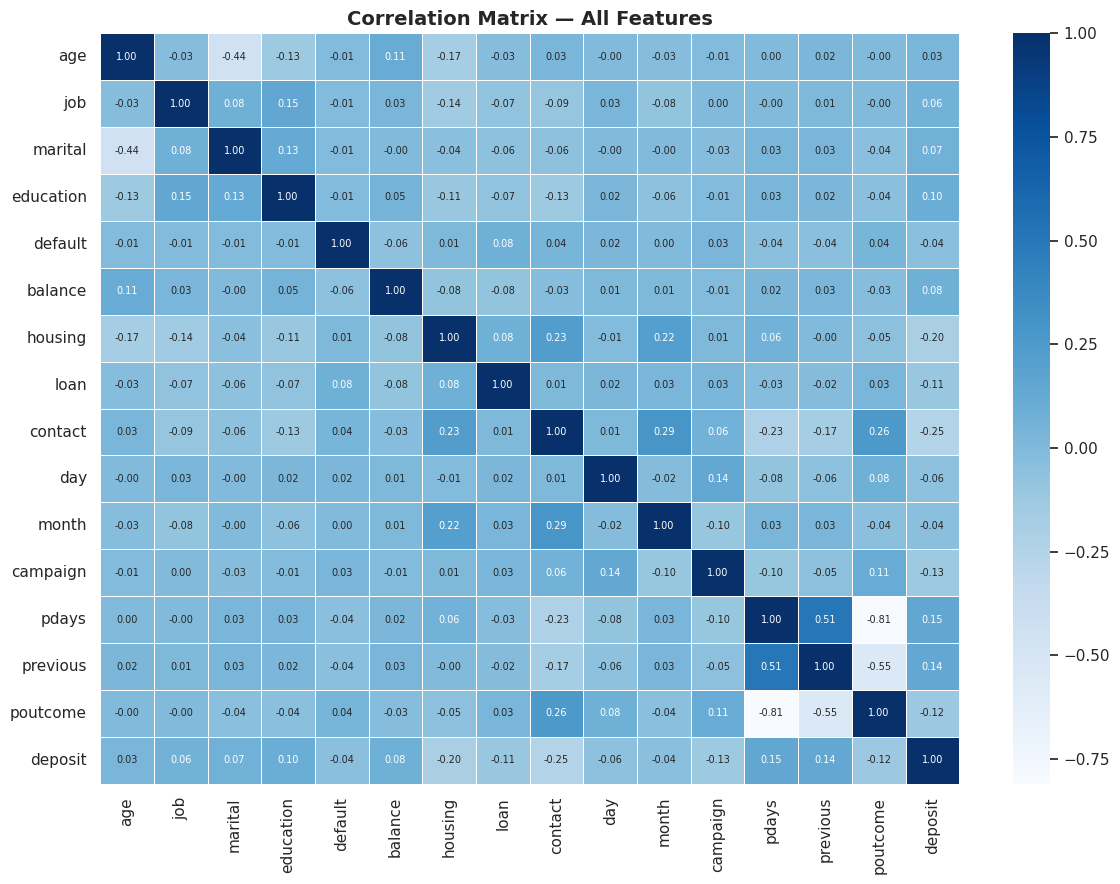

In [70]:
# Correlation Matrix
df_enc = df_tree.copy()
le = LabelEncoder()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col])

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df_enc.corr().round(2)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 7})
ax.set_title('Correlation Matrix — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
X_tree = df_enc.drop('deposit', axis=1)
y_tree = df_enc['deposit']

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree,
    test_size=0.25,
    random_state=42,
    stratify=y_tree
)

print(f'Train : {X_tree_train.shape[0]:,} samples')
print(f'Test  : {X_tree_test.shape[0]:,} samples')
print(f'Features : {list(X_tree.columns)}')

Train : 8,371 samples
Test  : 2,791 samples
Features : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


  BAGGING — Classification Report
              precision    recall  f1-score   support

          no       0.70      0.81      0.75      1469
         yes       0.74      0.62      0.68      1322

    accuracy                           0.72      2791
   macro avg       0.72      0.71      0.71      2791
weighted avg       0.72      0.72      0.72      2791

  ROC-AUC : 0.7725


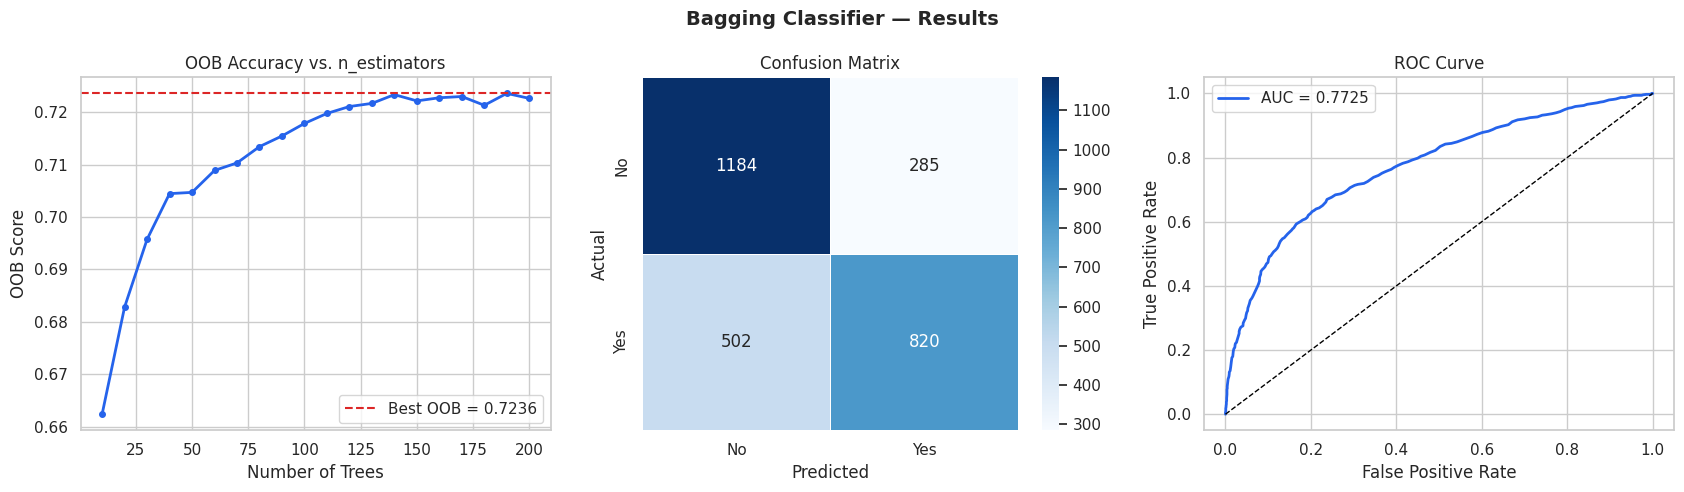

In [72]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_features='sqrt'),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bag_clf.fit(X_tree_train, y_tree_train)

bag_pred = bag_clf.predict(X_tree_test)
bag_prob = bag_clf.predict_proba(X_tree_test)[:, 1]

print('=' * 50)
print('  BAGGING — Classification Report')
print('=' * 50)
print(classification_report(y_tree_test, bag_pred, target_names=['no', 'yes']))
print(f'  ROC-AUC : {roc_auc_score(y_tree_test, bag_prob):.4f}')

oob_scores, n_range = [], list(range(10, 201, 10))
bag_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_features='sqrt'),
    n_estimators=10,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
for n in n_range:
    bag_oob.set_params(n_estimators=n)
    bag_oob.fit(X_tree_train, y_tree_train)
    oob_scores.append(bag_oob.oob_score_)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Bagging Classifier — Results', fontsize=14, fontweight='bold')

axes[0].plot(n_range, oob_scores, color='#2563EB', linewidth=2, marker='o', ms=4)
axes[0].axhline(max(oob_scores), color='#DC2626', linestyle='--', label=f'Best OOB = {max(oob_scores):.4f}')
axes[0].set_title('OOB Accuracy vs. n_estimators')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('OOB Score')
axes[0].legend()

cm = confusion_matrix(y_tree_test, bag_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_tree_test, bag_prob)
auc = roc_auc_score(y_tree_test, bag_prob)
axes[2].plot(fpr, tpr, color='#2563EB', linewidth=2, label=f'AUC = {auc:.4f}')
axes[2].plot([0,1], [0,1], 'k--', linewidth=1)
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

          no       0.71      0.80      0.75      1469
         yes       0.74      0.64      0.69      1322

    accuracy                           0.72      2791
   macro avg       0.73      0.72      0.72      2791
weighted avg       0.73      0.72      0.72      2791

  ROC-AUC   : 0.7790
  5-Fold CV : 0.7317  ±  0.1756


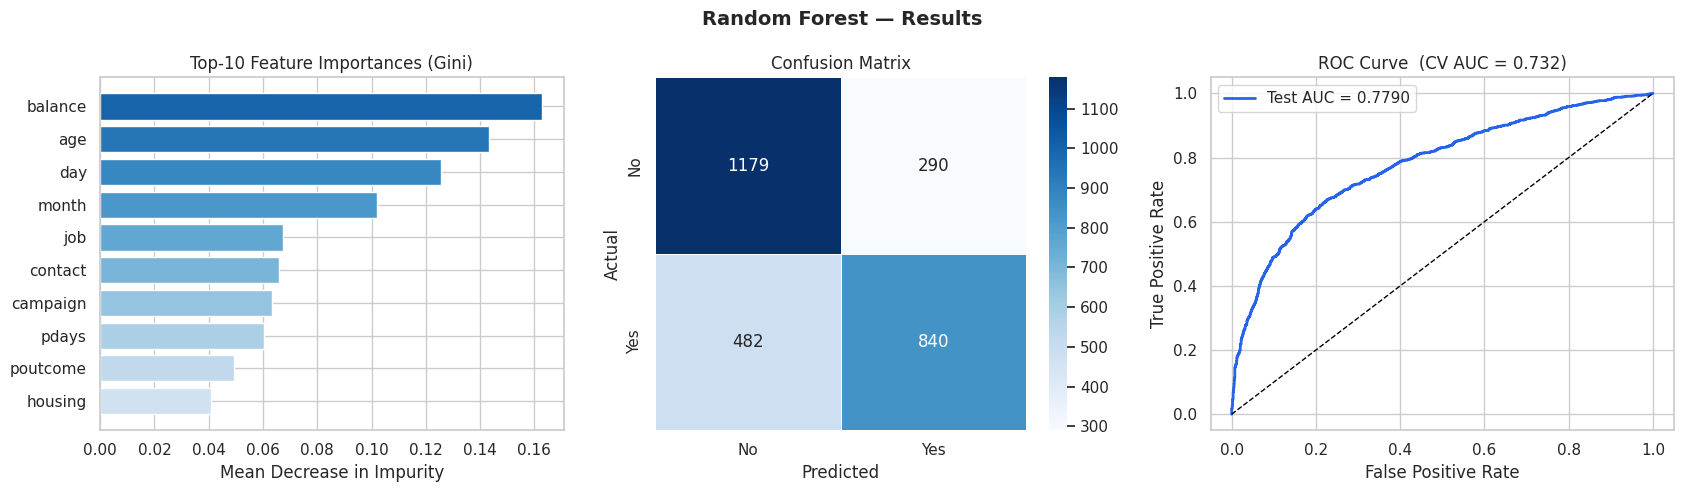

In [73]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_tree_train, y_tree_train)

rf_pred = rf_clf.predict(X_tree_test)
rf_prob = rf_clf.predict_proba(X_tree_test)[:, 1]
cv = cross_val_score(rf_clf, X_tree, y_tree, cv=5, scoring='roc_auc', n_jobs=-1)

print('=' * 50)
print('  RANDOM FOREST — Classification Report')
print('=' * 50)
print(classification_report(y_tree_test, rf_pred, target_names=['no', 'yes']))
print(f'  ROC-AUC   : {roc_auc_score(y_tree_test, rf_prob):.4f}')
print(f'  5-Fold CV : {cv.mean():.4f}  ±  {cv.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Random Forest — Results', fontsize=14, fontweight='bold')

feat_imp = (pd.Series(rf_clf.feature_importances_, index=X_tree.columns)
              .sort_values(ascending=False)
              .head(10))
colors_fi = plt.cm.Blues_r(np.linspace(0.2, 0.8, len(feat_imp)))
axes[0].barh(feat_imp.index[::-1], feat_imp.values[::-1],
             color=colors_fi[::-1], edgecolor='white')
axes[0].set_title('Top-10 Feature Importances (Gini)')
axes[0].set_xlabel('Mean Decrease in Impurity')

cm = confusion_matrix(y_tree_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_tree_test, rf_prob)
auc = roc_auc_score(y_tree_test, rf_prob)
axes[2].plot(fpr, tpr, color='#2563EB', linewidth=2, label=f'Test AUC = {auc:.4f}')
axes[2].plot([0,1], [0,1], 'k--', linewidth=1)
axes[2].set_title(f'ROC Curve  (CV AUC = {cv.mean():.3f})')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

  GRADIENT BOOSTING — Classification Report
              precision    recall  f1-score   support

          no       0.71      0.83      0.77      1469
         yes       0.76      0.63      0.69      1322

    accuracy                           0.73      2791
   macro avg       0.74      0.73      0.73      2791
weighted avg       0.74      0.73      0.73      2791

  ROC-AUC : 0.7894


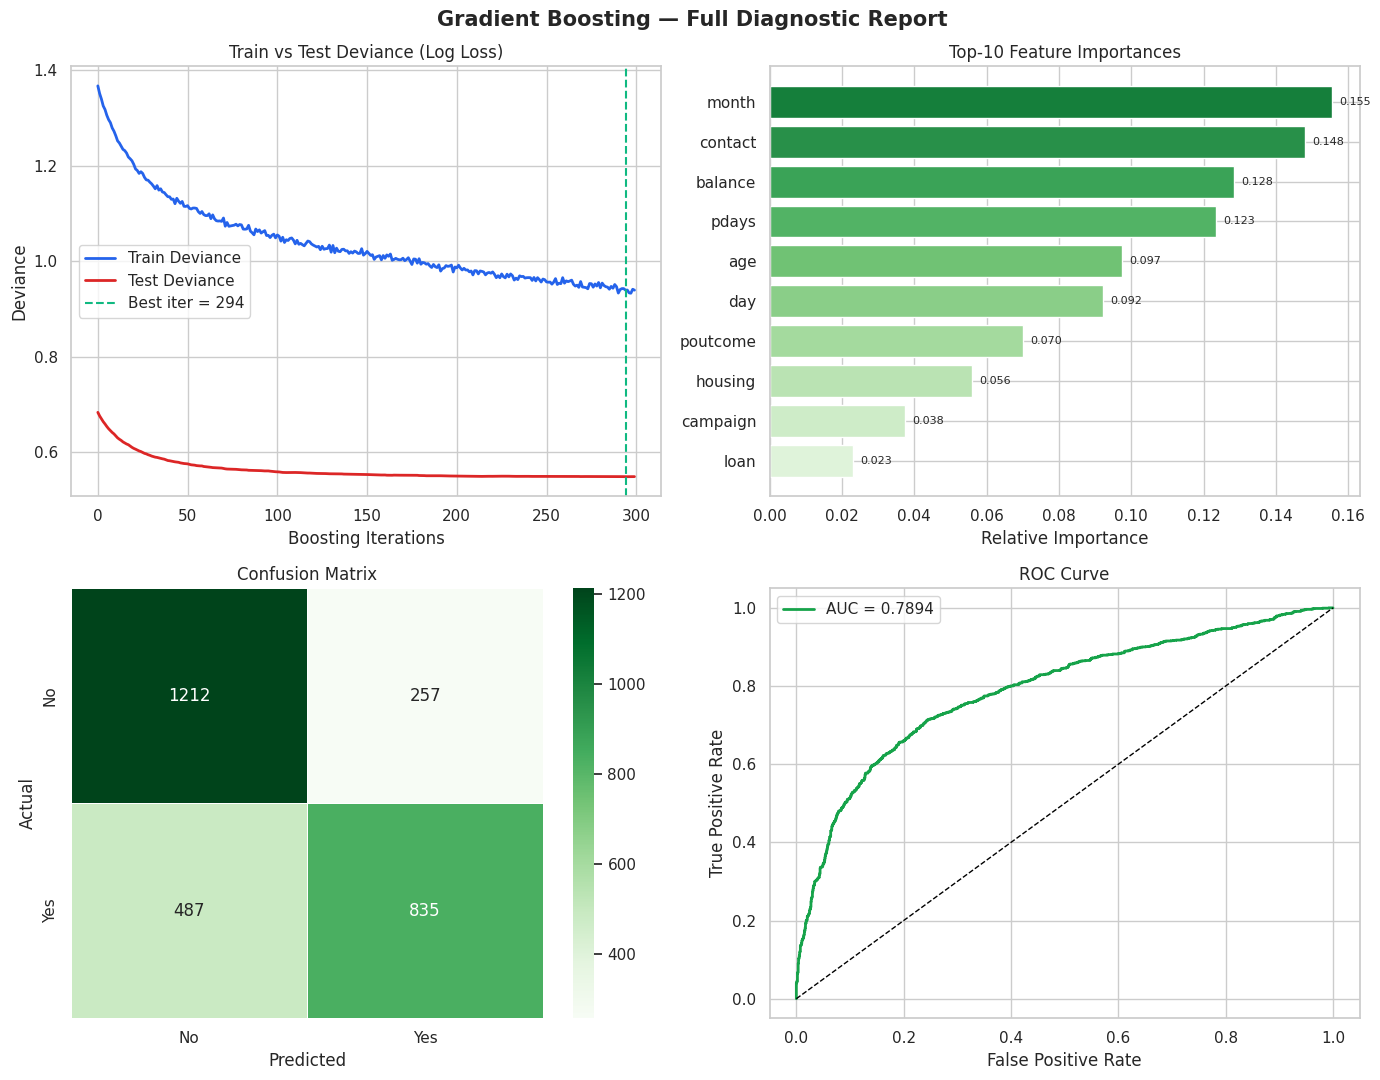

In [74]:
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb_clf.fit(X_tree_train, y_tree_train)

gb_pred = gb_clf.predict(X_tree_test)
gb_prob = gb_clf.predict_proba(X_tree_test)[:, 1]

print('=' * 50)
print('  GRADIENT BOOSTING — Classification Report')
print('=' * 50)
print(classification_report(y_tree_test, gb_pred, target_names=['no', 'yes']))
print(f'  ROC-AUC : {roc_auc_score(y_tree_test, gb_prob):.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Gradient Boosting — Full Diagnostic Report', fontsize=15, fontweight='bold')

gb_staged_loss = [log_loss(y_tree_test, p[:, 1]) for p in gb_clf.staged_predict_proba(X_tree_test)]

axes[0, 0].plot(gb_clf.train_score_, color='#2563EB', linewidth=2, label='Train Deviance')
axes[0, 0].plot(gb_staged_loss, color='#DC2626', linewidth=2, label='Test Deviance')
best_iter = int(np.argmin(gb_staged_loss))
axes[0, 0].axvline(best_iter, color='#10B981', linestyle='--', label=f'Best iter = {best_iter}')
axes[0, 0].set_title('Train vs Test Deviance (Log Loss)')
axes[0, 0].set_xlabel('Boosting Iterations')
axes[0, 0].set_ylabel('Deviance')
axes[0, 0].legend()

feat_imp = (pd.Series(gb_clf.feature_importances_, index=X_tree.columns)
              .sort_values(ascending=False)
              .head(10))
colors_gb = plt.cm.Greens_r(np.linspace(0.2, 0.85, len(feat_imp)))
axes[0, 1].barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors_gb[::-1], edgecolor='white')
axes[0, 1].set_title('Top-10 Feature Importances')
axes[0, 1].set_xlabel('Relative Importance')
for i, v in enumerate(feat_imp.values[::-1]):
    axes[0, 1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

cm = confusion_matrix(y_tree_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            linewidths=0.5, linecolor='white')
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_tree_test, gb_prob)
auc = roc_auc_score(y_tree_test, gb_prob)
axes[1, 1].plot(fpr, tpr, color='#16A34A', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1, 1].set_title('ROC Curve')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [75]:
models = {
    'Bagging Classifier': (bag_pred, bag_prob),
    'Random Forest Classifier': (rf_pred, rf_prob),
    'Gradient Boosting Classifier': (gb_pred, gb_prob),
}

rows = []
for name, (p, pr) in models.items():
    rows.append({
        'model': name,
        'accuracy': round(accuracy_score(y_tree_test, p), 4),
        'precision': round(precision_score(y_tree_test, p), 4),
        'recall': round(recall_score(y_tree_test, p), 4),
        'f1': round(f1_score(y_tree_test, p), 4),
        'roc_auc': round(roc_auc_score(y_tree_test, pr), 4),
    })

tree_summary_df = pd.DataFrame(rows)
display(tree_summary_df)

,model,accuracy,precision,recall,f1,roc_auc
0,Bagging Classifier,0.7180,0.7421,0.6203,0.6757,0.7725
1,Random Forest Classifier,0.7234,0.7434,0.6354,0.6852,0.7790
2,Gradient Boosting Classifier,0.7334,0.7647,0.6316,0.6918,0.7894


## 6. Final Comparison

In [76]:
final_comparison_df = pd.concat([
    baseline_results,
    nonlinear_cls_df,
    svm_cls_df,
    tree_summary_df,
], ignore_index=True).drop_duplicates(subset='model').sort_values(
    ['accuracy', 'f1', 'roc_auc'], ascending=False
).reset_index(drop=True)

display(final_comparison_df)

,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting Classifier,0.733400,0.764700,0.631600,0.691800,0.789400
1,Random Forest Classifier,0.723400,0.743400,0.635400,0.685200,0.779000
2,Bagging Classifier,0.718000,0.742100,0.620300,0.675700,0.772500
3,SVM RBF,0.715156,0.771930,0.565809,0.652990,0.768682
4,SVM Polynomial,0.709423,0.788701,0.527988,0.632533,0.767155
5,Spline Logistic,0.706915,0.746575,0.577156,0.651024,0.765268
6,Step Function Logistic,0.706557,0.740210,0.586233,0.654285,0.762634
7,GAM-style Logistic,0.704049,0.745059,0.570348,0.646101,0.762688
8,Polynomial Logistic,0.702616,0.744048,0.567322,0.643777,0.760845
9,Baseline Logistic Regression,0.696883,0.736111,0.561271,0.636910,0.757358


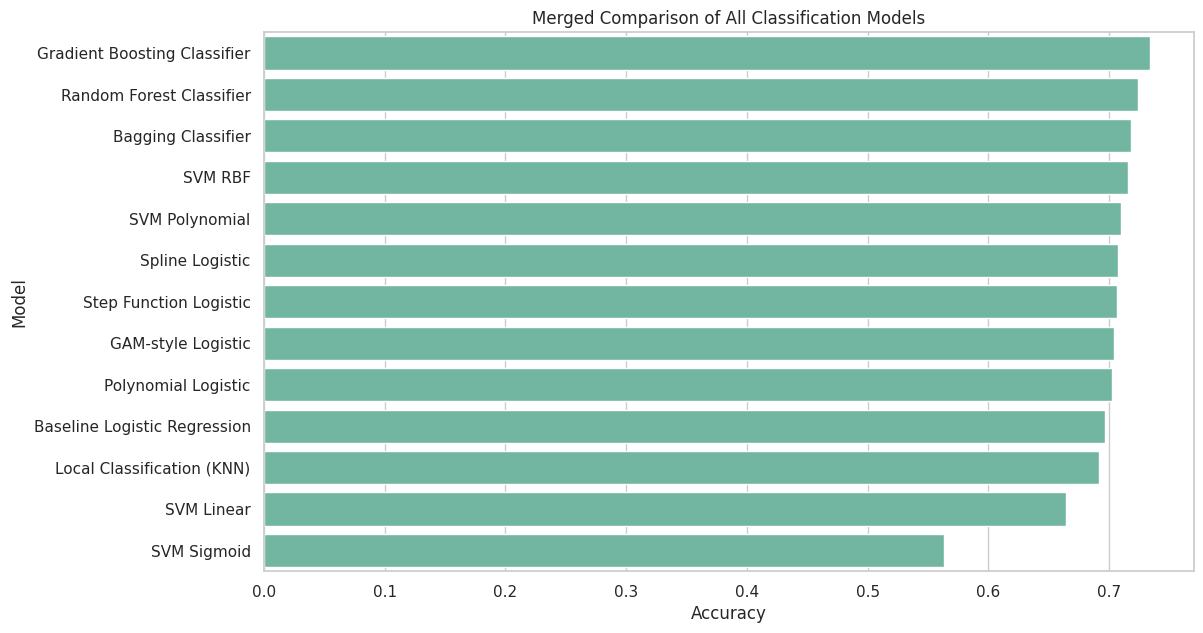

In [77]:
plt.figure(figsize=(12, 7))
sns.barplot(data=final_comparison_df, x='accuracy', y='model')
plt.title('Merged Comparison of All Classification Models')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.show()

## 7. Save Results

In [78]:
final_comparison_df.to_csv('merged_preserved_classification_results.csv', index=False)
tree_summary_df.to_csv('merged_preserved_tree_results.csv', index=False)
nonlinear_cls_df.to_csv('merged_preserved_nonlinear_results.csv', index=False)
svm_cls_df.to_csv('merged_preserved_svm_results.csv', index=False)
print('Files saved successfully.')

Files saved successfully.
